# Boxplot: Convective Environment Parameters by Lightning/OT Category (Land vs Ocean)

Purpose: Visualize distributions of convective environment parameters (CAPE, QPI, TPI, LCL,
LR36, RH36) across lightning/OT co-occurrence categories (OT only, OT+LS, LS only),
comparing land vs. ocean, using boxplots built from precomputed summary statistics.

Input:
- Precomputed summary statistics: warm_season_stats_parameter.csv
  (from 07_categorical_environment_stats.ipynb)
- Variable metadata (name, display title, unit) for 6 parameters: MUCAPE, MULPLmixr,
  MULPLtemp, MULCL, LR36, RH36mean

Processing:
1. Load precomputed per-category, per-contrast summary statistics (Q1, median, mean, Q3,
   min, max, whiskers) for each environment variable.
2. Apply unit scaling/conversion per variable (e.g. x1000 for LR36/MULPLmixr, /1000 for
   MULCL, Kelvin-to-Celsius conversion for MULPLtemp).
3. Build a 2x3 grid of boxplots (one panel per variable), each showing Land vs Ocean
   boxes side-by-side within each lightning/OT category group.
4. Style each panel with custom colors, dynamic y-axis limits (from the data's whisker
   range), gridlines, and panel labels (a-f).

Output:
- Figure saved to:
  /g/data/if69/tp4064/Project_1/Plots/warm_season/1_warm_season_box_plot.png

In [1]:
# Standard libraries
import os
import glob

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches


In [2]:
#Inputs
box_stats_df = pd.read_csv("/g/data/if69/tp4064/Project_1/categorical_position/Box_plot/Box_plot_parameter/warm_season_stats_parameter.csv")

variables = [
    {'name': 'MUCAPE',    'title' : 'CAPE', 'unit' : "J.kg$^{-1}$"},
    {'name': 'MULPLmixr', 'title' : 'QPI', 'unit' : "g.kg$^{-1}$"},
    {'name': 'MULPLtemp', 'title' : 'TPI', 'unit' : "°C"},
    {'name': 'MULCL',     'title' : 'LCL', 'unit' : "km"},
    {'name': 'LR36',      'title' : 'LR36', 'unit' : "°C·km$^{-1}$"},
    {'name': 'RH36mean',  'title' : 'RH36', 'unit' : "%"},    
]


yes


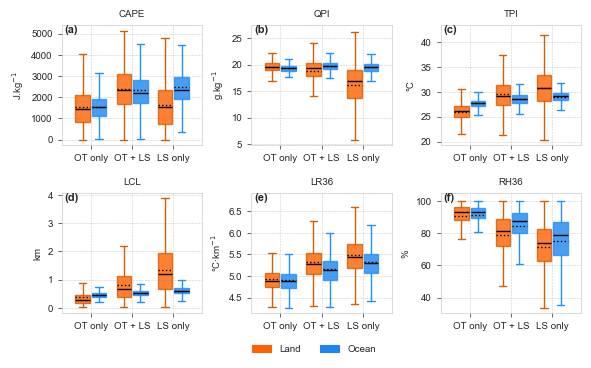

In [4]:
# Plotting
sns.set_theme(style="white", context="paper")

# --- Figure setup ---
fig, axes = plt.subplots(2, 3, figsize=(6, 3.5))
axes = axes.flatten()

# Variables needing unit scaling
SCALE_1000 = {'LR03', 'LR36', 'MULPLmixr'}   # × 1000
SCALE_DIV  = {'MULCL'}                # ÷ 1000
SCALE_SUB = {'MULPLtemp'} #-273.15

# --- Colors ---
edge_color = {'Land': '#D55E00', 'Ocean': '#1E90FF'}
fill_color = {'Land': '#FE6100', 'Ocean': '#1C86EE'}

font_size = 7

# --- Loop over variables ---
for i, v in enumerate(variables):
    ax = axes[i]
    var = v['name']
    subset = box_stats_df[box_stats_df['variable'] == var]
    subset = subset.copy()
    
    cols = ['Q1', 'Median', 'Mean', 'Q3', 'Min', 'Max', 'IQR','Lower Whisker', 'Upper Whisker']

    if var in SCALE_1000:
        
        subset.loc[:,cols] = subset.loc[:,cols] * 1000

    elif var in SCALE_DIV:
        
        subset.loc[:,cols] = subset.loc[:,cols] / 1000

    elif var in SCALE_SUB:

        print('yes')

        subset.loc[:,cols] = subset.loc[:,cols]-273.15
        
        


    groups = sorted(subset['group'].unique(), reverse=True)

    stats, positions, contrasts = [], [], []

    # --- Build stats ---
    for g_idx, group in enumerate(groups):
        for contrast, shift in zip(['Land', 'Ocean'], [-0.2, 0.2]):
            row = subset[(subset['group'] == group) & (subset['contrast'] == contrast)]
            if row.empty:
                continue

            r = row.iloc[0]

            stats.append({
                'med': r['Median'],
                'q1': r['Q1'],
                'q3': r['Q3'],
                'whislo': r['Lower Whisker'],
                'whishi': r['Upper Whisker'],
                'mean': r['Mean']
            })

            positions.append(g_idx + shift)
            contrasts.append(contrast)

    # --- Plot once ---
    bp = ax.bxp(
        stats,
        positions=positions,
        widths=0.35,
        showmeans=True,
        meanline=True,   # ✅ use line instead of marker
        showfliers=False,
        patch_artist=True
    )

    

    # --- Styling ---
    for j, box in enumerate(bp['boxes']):
        c = contrasts[j]
        box.set(facecolor=fill_color[c], edgecolor=edge_color[c], linewidth=1, alpha=0.8)

        # whiskers & caps
        for k in [2*j, 2*j+1]:
            bp['whiskers'][k].set(color=edge_color[c], linewidth=1)
            bp['caps'][k].set(color=edge_color[c], linewidth=1)

    # median & mean
    for med in bp['medians']:
        med.set(color='black', linewidth=1)

    for mean in bp['means']:
        mean.set(color='black', linestyle='dotted', linewidth=1)

    # --- Axes ---
    ax.grid(True, linestyle='--', linewidth=0.4, color='#cccccc', zorder=0) #
    ax.set_axisbelow(True)
    
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups, fontsize = font_size+1)
    
    ax.set_title(v['title'], fontsize=font_size)
    ax.set_ylabel(v['unit'], fontsize=font_size)
    
    # ax.tick_params(axis='both', labelsize=font_size)
    ax.tick_params(axis='both', labelsize=font_size, direction='out', length=3, width=0.5, bottom=True, left=True)

    y_min = subset['Lower Whisker'].min()
    y_max = subset['Upper Whisker'].max()
    pad = (y_max-y_min)*0.05
    ax.set_ylim(y_min - pad, y_max * 1.05)  # small padding on top only, none on bottom
    

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#cccccc')  # or 'black' if you want it darker/thicker like we discussed
        spine.set_linewidth(0.5)

# --- Legend ---
legend_handles = [
    mpatches.Patch(color=fill_color['Land'], label='Land'),
    mpatches.Patch(color=fill_color['Ocean'], label='Ocean')
]

fig.legend(handles=legend_handles, loc='lower center', ncol=2,
           frameon=False, fontsize=font_size, bbox_to_anchor=(0.53, -0.05))

# --- Panel labels ---
labels = ['a', 'b', 'c', 'd', 'e', 'f']
for i, ax in enumerate(axes):
    ax.text(0.02, 1, f"({labels[i]})",
            transform=ax.transAxes, fontsize=font_size+1, fontweight='bold',
            va='top')

# --- Layout ---
plt.tight_layout()
# plt.tight_layout(rect=[0.01, 0.01, 0.97, 0.97])
plt.subplots_adjust(hspace=0.4, wspace=0.35)
plt.savefig("/g/data/if69/tp4064/Project_1/Plots/warm_season/1_warm_season_box_plot.png", dpi = 400 ,bbox_inches='tight')

plt.show()
